*heteroTests tutorial series — [01. Detecting heteroscedasticity](01-detecting-heteroscedasticity.ipynb) · [02. Remediation](02-remediating-heteroscedasticity.ipynb) · [03. Modern & scalable diagnostics](03-modern-and-scalable.ipynb) · **04. Group-wise variance tests** · [05. Time series & ARCH effects](05-time-series-arch.ipynb) · [06. Choosing a test: a power study](06-choosing-a-test.ipynb)*


# Group-wise Variance Tests

**Comparing dispersion across groups --- and the normality trap**

---

Not all heteroscedasticity is a smooth function of a continuous regressor.
Often the variance differs across *groups*: treatments in an experiment,
sites in a survey, regimes in a panel. The relevant question becomes
$H_0:\sigma_1^2 = \sigma_2^2 = \cdots = \sigma_g^2$, and the right tools are the
group-comparison tests.

`heteroTests` provides the classical and robust members of this family:
**Bartlett**, **Levene**, **Brown--Forsythe** and **Fligner--Killeen**. This
notebook applies them to a textbook data set, validates against `car`, and then
shows --- with a simulation --- why the choice between them matters enormously
when the data are not normal.


In [1]:
library(heteroTests)
ht_set_log_level("SILENT")  # keep simulation loops quiet
library(ggplot2)
theme_set(theme_minimal(base_size = 12))
options(digits = 4)


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


## 1. The data

`InsectSprays` records insect counts under six spray treatments. Count data
typically show variance that grows with the mean, so the groups are a natural
candidate for unequal dispersion.


In [2]:
data(InsectSprays)
InsectSprays$spray <- factor(InsectSprays$spray)
round(tapply(InsectSprays$count, InsectSprays$spray, sd), 2)


A    B    C    D    E    F 
4.72 4.27 1.98 2.50 1.73 6.21

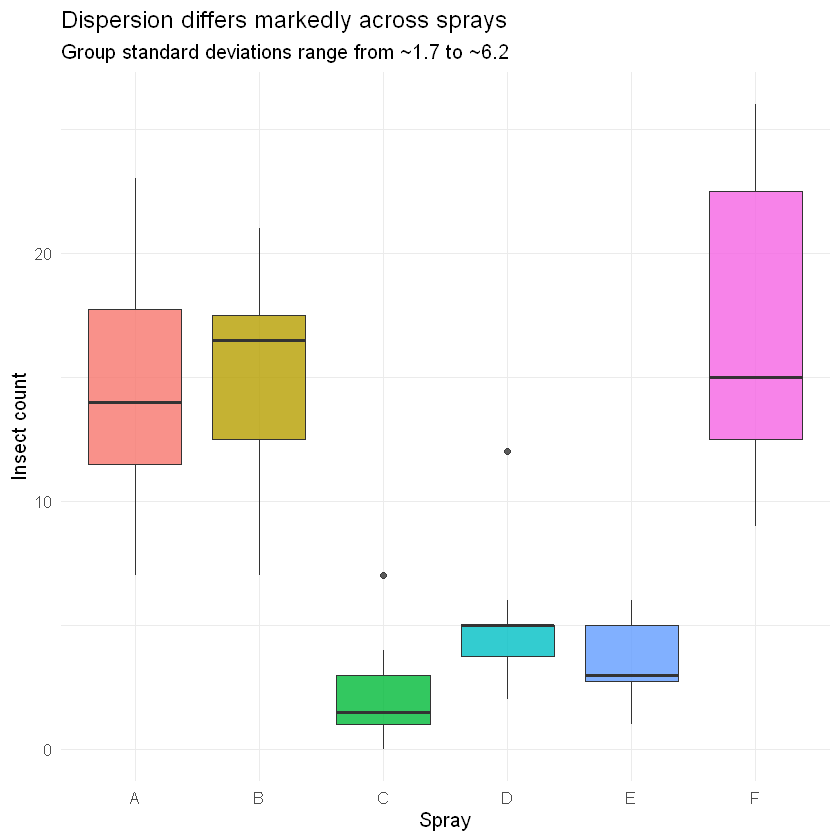

In [3]:
ggplot(InsectSprays, aes(spray, count, fill = spray)) +
  geom_boxplot(show.legend = FALSE, alpha = 0.8) +
  labs(x = "Spray", y = "Insect count",
       title = "Dispersion differs markedly across sprays",
       subtitle = "Group standard deviations range from ~1.7 to ~6.2")


The boxes have visibly different heights: sprays C and E are tight, while A, B
and F are dispersed. The group standard deviations span more than a threefold
range. Now we test it formally.


## 2. The four tests

Each test reduces to a one-way analysis of dispersion, differing in *what they
analyse*:

| Test | Operates on | Normality assumption |
|------|-------------|----------------------|
| **Bartlett** | group variances (likelihood ratio) | strong --- assumes normal data |
| **Levene** | $|y_{ij}-\bar y_j|$ (deviations from the mean) | weak |
| **Brown--Forsythe** | $|y_{ij}-\tilde y_j|$ (deviations from the median) | weakest (most robust) |
| **Fligner--Killeen** | ranks of absolute deviations | rank-based, very robust |

All share the package signature `perform*Test(model, data, group)`, where
`model` supplies the residuals and `group` names the factor.


In [4]:
m <- lm(count ~ 1, data = InsectSprays)
summarise <- function(x, label) data.frame(
  Test = label, Statistic = round(unname(x$statistic), 3),
  p.value = signif(x$p.value, 3), Reject_5pct = x$p.value < 0.05)
do.call(rbind, list(
  summarise(performBartlettTest(m, InsectSprays, "spray"),       "Bartlett"),
  summarise(performLeveneTest(m, InsectSprays, "spray"),         "Levene"),
  summarise(performBrownForsytheTest(m, InsectSprays, "spray"),  "Brown-Forsythe"),
  summarise(performFlignerKilleenTest(m, InsectSprays, "spray"), "Fligner-Killeen")))


Warning message:
"Severe non-normality detected in '.__residuals__' (p = 0.000)."


Test,Statistic,p.value,Reject_5pct
<chr>,<dbl>,<dbl>,<lgl>
Bartlett,25.960,9.09e-05,TRUE
Levene,6.455,6.10e-05,TRUE
Brown-Forsythe,3.821,4.22e-03,TRUE
Fligner-Killeen,15.451,8.60e-03,TRUE


All four agree: the variances are not equal. They will not always agree so
neatly --- which is the point of the next section.


### Validation against `car`

The Levene implementation should reproduce `car::leveneTest` (mean-centred) to
machine precision.


In [5]:
ours <- performLeveneTest(m, InsectSprays, "spray")
ref  <- car::leveneTest(count ~ spray, data = InsectSprays, center = mean)
c(ours = unname(ours$statistic),
  car  = ref[["F value"]][1],
  agree = isTRUE(all.equal(unname(ours$statistic), ref[["F value"]][1])))


ours   car agree 
6.455 6.455 1.000

## 3. The normality trap

Bartlett's test is the most powerful of the four *when the data are normal* ---
but it derives its null distribution from that normality assumption. Under heavy
tails it confuses kurtosis for unequal variance and rejects a true null far too
often. The robust tests (Levene, Brown--Forsythe, Fligner--Killeen) were designed
precisely to avoid this.

We verify it: simulate groups with **equal variances** but heavy-tailed $t_3$
errors, and measure the rejection rate at the nominal 5% level.


In [6]:
size_study <- function(rng, ng = 4, npg = 25, reps = 200) {
  hit <- c(Bartlett = 0, Levene = 0, `Brown-Forsythe` = 0, `Fligner-Killeen` = 0)
  for (i in seq_len(reps)) {
    g <- factor(rep(seq_len(ng), each = npg))
    d <- data.frame(y = rng(ng * npg), g = g)   # identical dist => equal variance
    m <- lm(y ~ 1, data = d)
    hit["Bartlett"]        <- hit["Bartlett"]        + (performBartlettTest(m, d, "g")$p.value < 0.05)
    hit["Levene"]          <- hit["Levene"]          + (performLeveneTest(m, d, "g")$p.value < 0.05)
    hit["Brown-Forsythe"]  <- hit["Brown-Forsythe"]  + (performBrownForsytheTest(m, d, "g")$p.value < 0.05)
    hit["Fligner-Killeen"] <- hit["Fligner-Killeen"] + (performFlignerKilleenTest(m, d, "g")$p.value < 0.05)
  }
  round(100 * hit / reps, 1)
}
set.seed(7)
size_tab <- rbind(
  `Normal errors`        = size_study(function(n) rnorm(n)),
  `Heavy-tailed t(3)`    = size_study(function(n) rt(n, df = 3)))
size_tab


Warning message:
"Severe non-normality detected in '.__residuals__' (p = 0.006)."


Warning message:
"Severe non-normality detected in '.__residuals__' (p = 0.004)."


Warning message:
"Residual outliers detected at rows 4 (|z| > 5). Inspect leverage before running Bartlett."


Warning message:
"Severe non-normality detected in '.__residuals__' (p = 0.000)."


Warning message:
"Residual outliers detected at rows 4 (|z| > 5). Inspect leverage before running Levene."


...

Warning message:
"Residual outliers detected at rows 91 (|z| > 5). Inspect leverage before running Levene."


Warning message:
"Residual outliers detected at rows 91 (|z| > 5). Inspect leverage before running Brown-Forsythe."


Warning message:
"Residual outliers detected at rows 91 (|z| > 5). Inspect leverage before running Fligner-Killeen."


Warning message:
"Severe non-normality detected in '.__residuals__' (p = 0.000)."


,Bartlett,Levene,Brown-Forsythe,Fligner-Killeen
Normal errors,6,5.5,3.5,3.0
Heavy-tailed t(3),52,4.5,1.5,0.5


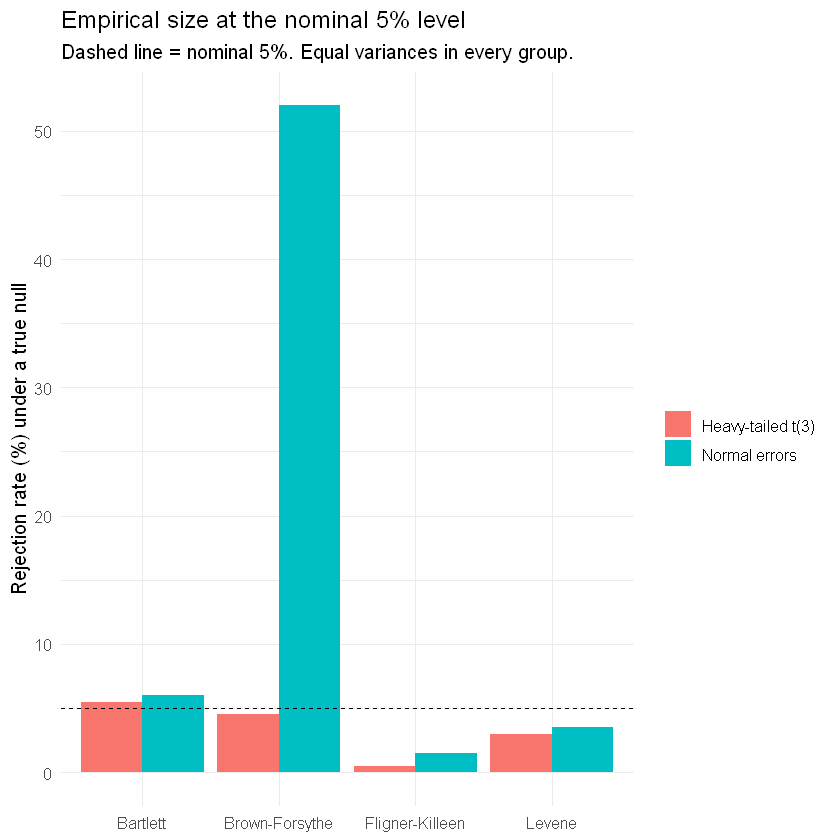

In [7]:
df_plot <- data.frame(
  test = rep(colnames(size_tab), each = 2),
  errors = rep(rownames(size_tab), times = ncol(size_tab)),
  size = as.vector(t(size_tab)))
ggplot(df_plot, aes(test, size, fill = errors)) +
  geom_col(position = "dodge") +
  geom_hline(yintercept = 5, linetype = "dashed") +
  labs(x = NULL, y = "Rejection rate (%) under a true null",
       fill = NULL, title = "Empirical size at the nominal 5% level",
       subtitle = "Dashed line = nominal 5%. Equal variances in every group.")


Under normal errors all four tests sit near 5%. Under $t_3$ errors **Bartlett
rejects roughly half the time** --- a false-positive rate an order of magnitude
too high --- while Levene, Brown--Forsythe and Fligner--Killeen stay close to
nominal. Bartlett is reading heavy tails as unequal variance.


## 4. Which test should you use?

- **Bartlett** --- most powerful *if you are confident the data are normal*
  (e.g. well-behaved measurement data). Avoid it otherwise.
- **Levene** --- the robust default; mean-centred absolute deviations, good power
  and good calibration. Matches `car::leveneTest`.
- **Brown--Forsythe** --- Levene with median centring; the most robust to skew and
  heavy tails, at a small cost in power.
- **Fligner--Killeen** --- rank-based and highly robust, a strong nonparametric
  choice when the distribution is unknown.

A practical rule: **default to Levene or Brown--Forsythe**, and reserve Bartlett
for data you have already checked for normality.

---


In [8]:
sessionInfo()


R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United Kingdom.utf8 
[2] LC_CTYPE=English_United Kingdom.utf8   
[3] LC_MONETARY=English_United Kingdom.utf8
[4] LC_NUMERIC=C                           
[5] LC_TIME=English_United Kingdom.utf8    

time zone: Europe/Lisbon
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.2     heteroTests_0.6.5

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     dplyr_1.2.0        compiler_4.5.1    
 [5] crayon_1.5.3       tidyselect_1.2.1   IRdisplay_1.1      systemfonts_1.3.1 
 [9] scales_1.4.0       textshaping_1.0.4  uuid_1.2-1         fastmap_1.2.0     
[13] IRkernel_1.3.2     R6_2.6.1           labeling_0.4.3     generics_0.1.4    
[17] Formula_1.2-5      MAS